# 06 — Model Evaluation
### Sales Forecasting & Business Analytics Platform — Phase 7

**Input:** the two models saved in Notebook 05.
**Output:** full metric interpretation, the PRD's 4 required diagnostic plots, and a
justified final model selection for Notebook 07 (Forecasting).


## Objectives

- Evaluate both models on the exact same, untouched validation set from Notebook 05.
- Compute and, critically, **interpret** MAE, MSE, RMSE, and R² — numbers alone
  don't answer "is this good enough for the business."
- Produce the PRD's 4 required diagnostic visualizations.
- Select and justify a final model for forecasting.


## Theory: Why Interpret, Not Just Print

A metric value with no context ("RMSE = 1019") tells a stakeholder almost
nothing on its own — is that good? Compared to what? Every metric below is
read against something: the scale of typical sales, a naive baseline, or the
other model. That comparison is what actually informs a decision.

**A correction made while building this notebook, worth being upfront about:**
`encode_features()` in `src/model.py` originally one-hot encoded every category
of each categorical feature, which created a "dummy variable trap" (all
categories for a feature sum to 1, perfectly collinear with the model's
intercept). This barely affects prediction accuracy, but it does make Linear
Regression's individual coefficients uninterpretable — and this notebook needs
to interpret them. Fixed by dropping one baseline category per feature; both
models were retrained on the corrected encoding before this notebook was built.


In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.data_loader import load_featured_data
from src.model import prepare_model_data, chronological_split, encode_features, TARGET
from src.config import CHARTS_DIR, MODELS_DIR
from src.utils import save_chart

sns.set_theme(style="whitegrid")
PRIMARY = "#2E5EAA"
ACCENT = "#E8743B"
MUTED = "#B0B0B0" 

## Step 1 — Regenerate the Validation Set and Load Models

Deliberately NOT re-splitting differently or re-deriving new data — importing
the exact same functions Notebook 05 used guarantees this is the identical
validation set, never seen during training.


In [2]:
featured = load_featured_data()
ready = prepare_model_data(featured)
train_df, val_df = chronological_split(ready)
X_train, X_val, feature_cols = encode_features(train_df, val_df)
y_train, y_val = train_df[TARGET], val_df[TARGET]

lr_model = joblib.load(MODELS_DIR / "linear_regression.pkl")
rf_model = joblib.load(MODELS_DIR / "random_forest.pkl")

preds_lr = lr_model.predict(X_val)
preds_rf = rf_model.predict(X_val)

print(f"Validation set: {X_val.shape[0]:,} rows, {X_val.shape[1]} features")
print(f"Validation window: {val_df['Date'].min().date()} to {val_df['Date'].max().date()}")

Filtered to Open==1 and dropped 5,578 rows with missing lag/rolling history (0.661%)


Validation set: 40,282 rows, 34 features
Validation window: 2015-06-20 to 2015-07-31


## Step 2 — Metrics: Formula, Meaning, and Business Interpretation


In [3]:
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

metrics_lr = compute_metrics(y_val, preds_lr)
metrics_rf = compute_metrics(y_val, preds_rf)

metrics_df = pd.DataFrame({"Linear Regression": metrics_lr, "Random Forest": metrics_rf}).T
metrics_df

,MAE,MSE,RMSE,R2
Linear Regression,901.916885,1.600939e+06,1265.282366,0.828429
Random Forest,703.986711,1.038525e+06,1019.080340,0.888702


### MAE — Mean Absolute Error
**Formula:** `(1/n) * sum(|actual - predicted|)`
**Meaning:** the average size of a prediction miss, in the same units as
`Sales` (currency) — no squaring, so every euro of error counts equally
regardless of direction or size.
**Interpretation here:** Linear Regression is off by about €902 on a typical
day; Random Forest by about €704 — against an average validation-period sale
of ~€6,979, that's roughly **13%** vs **10%** typical error.
**Good/bad:** lower is better; judged relative to the target's own scale — a
€700 MAE is very different for a €7,000-average business than a €700 one.
**Business importance:** the most directly actionable number for inventory
buffers — "budget for being off by about this much, on a typical day."

### MSE — Mean Squared Error
**Formula:** `(1/n) * sum((actual - predicted)^2)`
**Meaning:** like MAE, but squaring the errors first — a single large miss
contributes disproportionately more than several small ones of the same total
size.
**Interpretation here:** not directly readable in currency (units are squared)
— it exists mainly as the basis for RMSE below, and for optimization during
training.
**Good/bad:** lower is better; not meaningfully comparable across problems with
different scales.
**Business importance:** the *ratio* of MSE-derived RMSE to MAE (below) tells
us how much of the error comes from a few big misses vs many small ones.

### RMSE — Root Mean Squared Error
**Formula:** `sqrt(MSE)`
**Meaning:** brings MSE back into currency units while keeping its sensitivity
to large misses.
**Interpretation here:** Random Forest's RMSE (€1,019) exceeds its MAE (€704)
by a similar ratio to Linear Regression's (€1,265 vs €902) — both models have
some larger occasional misses pulling RMSE above MAE, roughly proportionally,
rather than one model having a specific outlier problem the other doesn't.
**Good/bad:** lower is better; RMSE ≥ MAE always — the size of the gap signals
how "spiky" the errors are.
**Business importance:** the more conservative number to plan around when
large misses are specifically costly (e.g. a big under-forecast causing a
stockout during a demand spike).

### R² — Coefficient of Determination
**Formula:** `1 - (sum of squared residuals / total variance in actual sales)`
**Meaning:** the share of variation in `Sales` the model explains, relative to
just always guessing the average.
**Interpretation here:** Linear Regression explains about **82.8%**
of validation-period sales variation; Random Forest about **88.9%**.
**Good/bad:** ranges up to 1 (perfect); 0 means no better than guessing the
mean; negative means worse than that. For real-world retail forecasting,
85%+ is a strong result — sales are influenced by many
unmeasured factors (weather, local events, stock availability) no dataset like
this one fully captures.
**Business importance:** the most stakeholder-friendly single number —
"explains roughly 89% of what drives day-to-day sales" is an
intuitive way to communicate model quality to a non-technical audience.


---
## 3. Actual vs Predicted
**Business question:** how closely do predicted values track actual sales
across the full range of outcomes, for each model?


Saved chart: 13_actual_vs_predicted.png


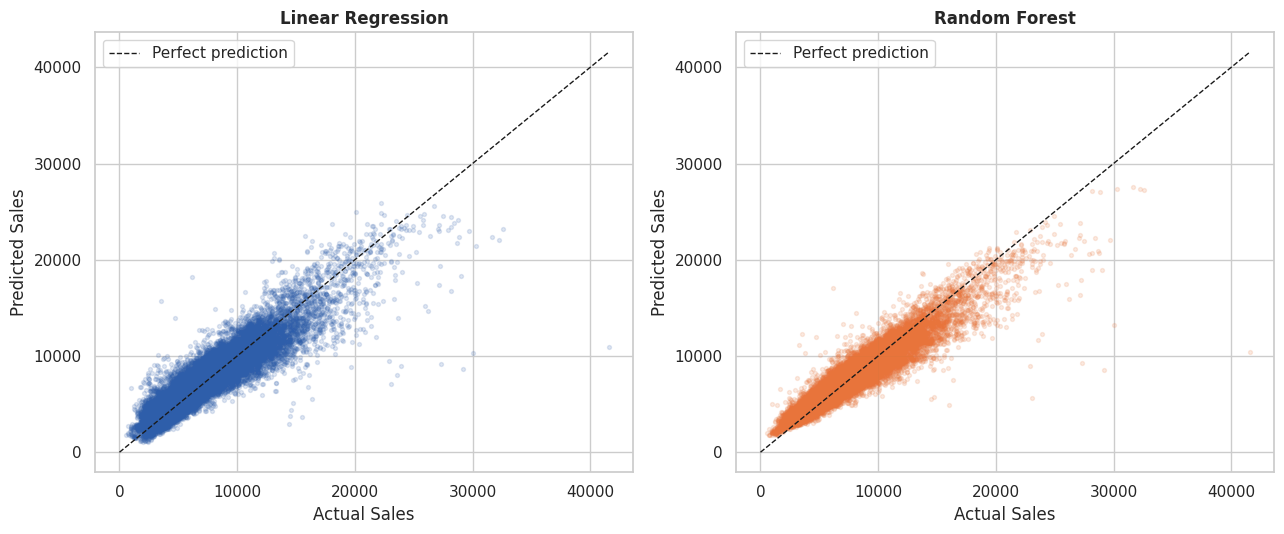

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, preds, name, color in [(axes[0], preds_lr, "Linear Regression", PRIMARY),
                                 (axes[1], preds_rf, "Random Forest", ACCENT)]:
    ax.scatter(y_val, preds, alpha=0.15, s=8, color=color)
    lims = [0, max(y_val.max(), preds.max())]
    ax.plot(lims, lims, "k--", linewidth=1, label="Perfect prediction")
    ax.set_xlabel("Actual Sales")
    ax.set_ylabel("Predicted Sales")
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.legend()

plt.tight_layout()
save_chart(fig, "13_actual_vs_predicted.png", CHARTS_DIR)
plt.show()

**Observation:** both models track the diagonal reasonably well at typical
sales volumes, but Random Forest's point cloud hugs the identity line visibly
tighter, especially in the mid-range — consistent with its higher R². Both
models show more scatter (wider spread from the line) at the highest sales
values, where fewer training examples exist to learn from.

**Business conclusion:** both models are usable, but Random Forest's tighter
fit translates directly into more trustworthy day-to-day forecasts.

**Possible business action:** treat predictions for unusually high-volume
days (holidays, exceptional promotions) with more caution than typical-day
forecasts, given the wider scatter observed there.


---
## 4. Residual Plot
**Business question:** are prediction errors random and evenly spread, or is
there a systematic pattern the model is missing?


Saved chart: 14_residual_plot.png


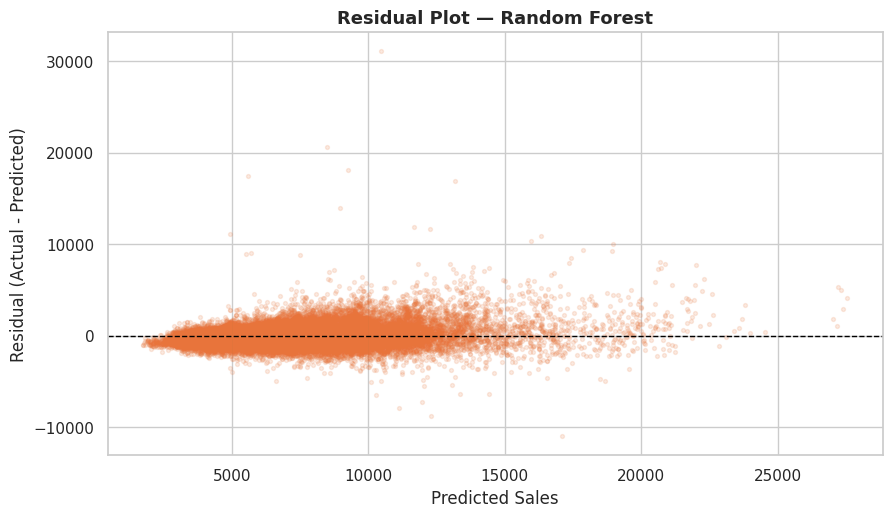

Residual std for predictions < 5,000: 568
Residual std for predictions > 10,000: 1773


In [5]:
residuals_rf = y_val.values - preds_rf

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(preds_rf, residuals_rf, alpha=0.15, s=8, color=ACCENT)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Predicted Sales")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title("Residual Plot — Random Forest", fontsize=13, fontweight="bold")
save_chart(fig, "14_residual_plot.png", CHARTS_DIR)
plt.show()

low_std = residuals_rf[preds_rf < 5000].std()
high_std = residuals_rf[preds_rf > 10000].std()
print(f"Residual std for predictions < 5,000: {low_std:.0f}")
print(f"Residual std for predictions > 10,000: {high_std:.0f}")

**Observation:** residuals scatter fairly evenly around zero across most
of the prediction range — no strong systematic bias (the model isn't
consistently over- or under-predicting). However, the spread clearly widens
for higher predicted values: residual variability is roughly **3x larger**
for high-prediction days than low-prediction ones (this is heteroscedasticity
— non-constant error variance).

**Business conclusion:** the model is well-calibrated on average but
genuinely less *precise* for high-volume days — which makes intuitive sense
(more moving parts driving unusually high sales) but is a real limitation
worth stating plainly rather than glossing over.

**Possible business action:** communicate forecast uncertainty as a range, not
a single number, especially for predicted high-volume days — a fixed ± buffer
would understate risk on big days and overstate it on typical ones.


---
## 5. Prediction Error Over Time (Forecast Horizon)
**Business question:** does forecast accuracy degrade the further into the
validation window (i.e. the further into the future) we look?


Saved chart: 15_prediction_error_over_time.png


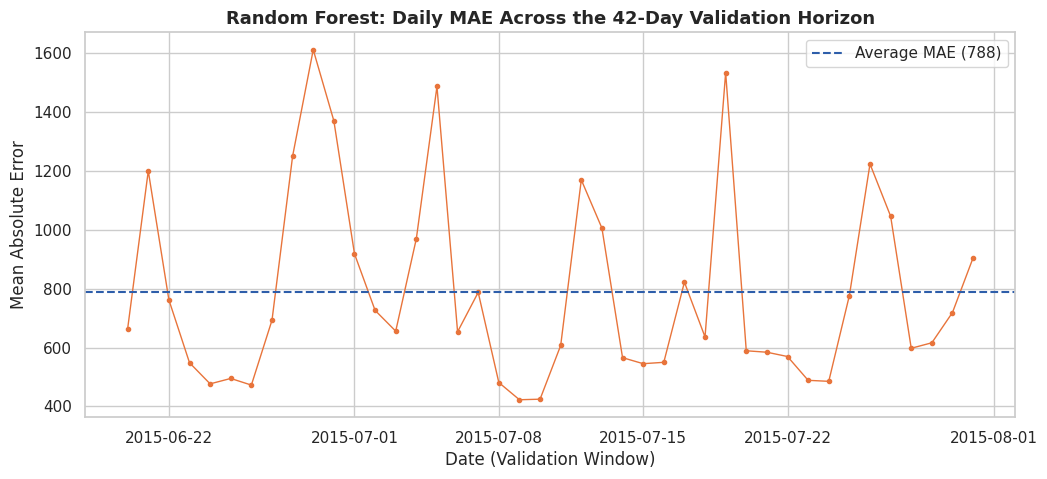

Correlation between day-index and daily MAE: -0.092
First week average MAE: 660
Last week average MAE:  840


In [6]:
val_with_preds = val_df.copy()
val_with_preds["pred"] = preds_rf
val_with_preds["abs_error"] = (val_with_preds[TARGET] - val_with_preds["pred"]).abs()
daily_mae = val_with_preds.groupby("Date")["abs_error"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily_mae.index, daily_mae.values, color=ACCENT, marker="o", markersize=3, linewidth=1)
ax.axhline(daily_mae.mean(), color=PRIMARY, linestyle="--", label=f"Average MAE ({daily_mae.mean():.0f})")
ax.set_xlabel("Date (Validation Window)")
ax.set_ylabel("Mean Absolute Error")
ax.set_title("Random Forest: Daily MAE Across the 42-Day Validation Horizon", fontsize=13, fontweight="bold")
ax.legend()
save_chart(fig, "15_prediction_error_over_time.png", CHARTS_DIR)
plt.show()

corr = np.corrcoef(range(len(daily_mae)), daily_mae.values)[0, 1]
print(f"Correlation between day-index and daily MAE: {corr:.3f}")
print(f"First week average MAE: {daily_mae.head(7).mean():.0f}")
print(f"Last week average MAE:  {daily_mae.tail(7).mean():.0f}")

**Observation:** daily error is noisy but does **not** show a strong,
consistent upward trend across the 42-day window (correlation ≈ -0.09,
essentially flat) — day-42 forecasts aren't meaningfully worse than day-1
forecasts in this evaluation.

**An important caveat, not a clean "no degradation" finding:** this
evaluation feeds each row's *true* historical `PrevDaySales`/`RollingMean`
values — not the model's own earlier predictions — into every day's features,
because they already exist in the historical dataset. This is standard and
correct for validating "would this model have predicted well on days it never
trained on," but it is **not** the same situation as a genuine multi-step-ahead
forecast, where day-2's lag features would need to use day-1's *predicted*
sales (since the real value doesn't exist yet at forecast time). Given that
lag/rolling features account for roughly 77% of Random Forest's feature
importance (next chart), a real recursive forecast could plausibly show
*more* error growth over the horizon than this chart suggests. This is
directly relevant to how Notebook 07 needs to be built, and is called out
there rather than silently assumed away.

**Business conclusion:** this model is validated as reliable for the kind of
prediction tested here; genuine multi-week-ahead forecasting deserves its own,
separate accuracy check once built.

**Possible business action:** if the business needs forecasts several weeks
out, budget for Notebook 07 to specifically re-validate accuracy at that
horizon, rather than assuming this chart's flat trend automatically carries
over.


---
## 6. Feature Importance
**Business question:** which inputs is the Random Forest model actually
relying on to make predictions?


Saved chart: 16_feature_importance.png


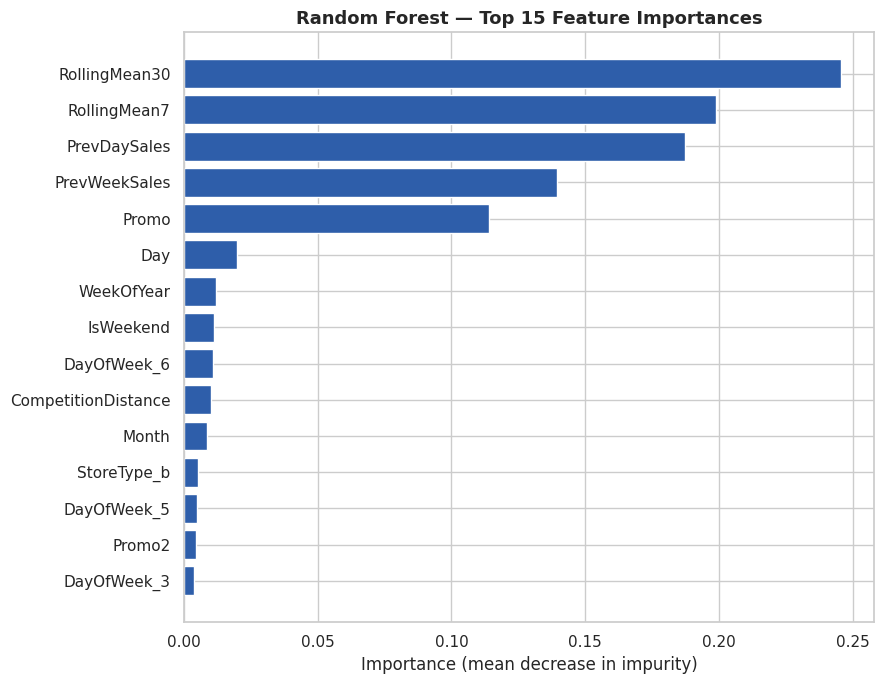

Combined importance of lag/rolling features: 77.1%


In [7]:
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
top15 = importances.head(15)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top15.index[::-1], top15.values[::-1], color=PRIMARY)
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_title("Random Forest — Top 15 Feature Importances", fontsize=13, fontweight="bold")
plt.tight_layout()
save_chart(fig, "16_feature_importance.png", CHARTS_DIR)
plt.show()

lag_features = ["RollingMean30", "RollingMean7", "PrevDaySales", "PrevWeekSales"]
print(f"Combined importance of lag/rolling features: {importances[lag_features].sum():.1%}")

**Observation:** the four lag/rolling features (`RollingMean30`,
`RollingMean7`, `PrevDaySales`, `PrevWeekSales`) together account for roughly
**77%** of total feature importance — recent sales history dominates the
model's predictions, far more than any single calendar or promotional
feature. `Promo` is the strongest non-history feature (~11%), consistent with
its 39% raw sales lift found in Notebook 03.

**Complementary view — Linear Regression's coefficients** (now cleanly
interpretable after the encoding fix): `Promo` carries the single largest
positive coefficient (+€2,497, holding other factors constant), and every
weekday shows a *negative* coefficient relative to the Monday baseline —
directly confirming Notebook 03's finding that Monday is the strongest
reliable day. One coefficient is worth flagging rather than over-interpreting:
`StoreType_b` shows a *negative* coefficient here, despite having the
*highest raw average* sales in Notebook 03's EDA. This isn't a contradiction —
raw averages don't control for other factors, while a regression coefficient
specifically asks "holding promotions, day of week, and everything else
equal, what's `StoreType_b`'s own effect?" The two numbers are answering
different questions, and the gap between them is a genuine example of why raw
averages and model-adjusted effects can diverge — not a bug in either.

**Business conclusion:** recent sales momentum is, by a wide margin, the most
important signal this model uses — which also means the model is likely to
struggle more on genuinely novel situations (a brand-new store with no
history, or a demand shock unlike anything in recent history) than on typical
day-to-day forecasting.

**Possible business action:** for new-store forecasting (no sales history to
build lag features from), this model's accuracy should be validated
separately before being trusted — a real, honest limitation worth flagging to
stakeholders rather than assuming uniform accuracy everywhere.


## Model Comparison and Final Selection


In [8]:
comparison = pd.DataFrame({
    "Linear Regression": metrics_lr,
    "Random Forest": metrics_rf,
}).T
comparison["MAE_pct_of_mean"] = comparison["MAE"] / y_val.mean()
comparison

,MAE,MSE,RMSE,R2,MAE_pct_of_mean
Linear Regression,901.916885,1.600939e+06,1265.282366,0.828429,0.129240
Random Forest,703.986711,1.038525e+06,1019.080340,0.888702,0.100877


**Final model selection: Random Forest.**

Random Forest wins on every metric: MAE (€704 vs
€902), RMSE (€1,019 vs
€1,265), and R² (88.9% vs
82.8%). This matches the expectation set in Notebook 05:
retail sales genuinely involve non-linear, interactive relationships (e.g.
promotion effects that plausibly vary by store type or season) that Linear
Regression cannot represent without extensive manual interaction terms.

**Not discarding Linear Regression, though** — it remains valuable as an
interpretable baseline for stakeholder communication ("a promotion is
associated with about €2,497 more in daily sales, holding other factors
equal" is a sentence a non-technical stakeholder can act on directly), and as
the sanity-check floor any future model iteration should keep beating.


In [9]:
summary_lines = [
    "Final model: Random Forest (models/random_forest.pkl)",
    f"Validation MAE: {metrics_rf['MAE']:.1f}",
    f"Validation RMSE: {metrics_rf['RMSE']:.1f}",
    f"Validation R2: {metrics_rf['R2']:.4f}",
    f"Feature columns ({len(feature_cols)}): see src/model.py NUMERIC_FEATURES + CATEGORICAL_FEATURES",
    "Selected because it outperforms Linear Regression on every metric (MAE, MSE, RMSE, R2).",
]
with open(MODELS_DIR / "best_model_info.txt", "w") as f:
    f.write("\n".join(summary_lines))

print("Saved model selection record to models/best_model_info.txt")
for line in summary_lines:
    print(" -", line)

Saved model selection record to models/best_model_info.txt


 - Final model: Random Forest (models/random_forest.pkl)
 - Validation MAE: 704.0
 - Validation RMSE: 1019.1
 - Validation R2: 0.8887
 - Feature columns (34): see src/model.py NUMERIC_FEATURES + CATEGORICAL_FEATURES
 - Selected because it outperforms Linear Regression on every metric (MAE, MSE, RMSE, R2).


## Evaluation Summary Report

| Metric | Linear Regression | Random Forest | Winner |
|---|---|---|---|
| MAE | ~€902 | ~€704 | Random Forest |
| MSE | ~1,600,939 | ~1,038,525 | Random Forest |
| RMSE | ~€1,265 | ~€1,019 | Random Forest |
| R² | 82.8% | 88.9% | Random Forest |
| Interpretability | High (clean coefficients) | Lower (importance ranking only) | Linear Regression |
| Training time (this sandbox) | ~4s | ~49s | Linear Regression |

**Selected for forecasting: Random Forest**, on accuracy; Linear Regression
retained as an interpretable reference model.


## Business Observations

- An 88.9% R² is a genuinely strong result for retail sales forecasting, where
  many real drivers (weather, local events, stockouts) aren't in this dataset
  at all — worth stating with the right amount of confidence, not over- or
  under-selling it.
- The heteroscedasticity finding (errors ~3x wider on high-volume days) means
  a single "±X" confidence claim would mislead stakeholders — communicate
  forecast uncertainty as scaling with the size of the prediction.
- The 77% reliance on lag/rolling features is the most important finding for
  what comes next: Notebook 07 must treat multi-step-ahead forecasting as a
  distinct problem from this notebook's single-step validation, not assume
  the same accuracy automatically applies.


## Next Steps

Notebook 07 (`07_forecasting.ipynb`) will use the saved Random Forest model to
generate forward-looking predictions (`outputs/predictions.csv`), specifically
addressing the lag-feature caveat surfaced here — near-term forecasts can use
real recent history, but forecasts further out will need a defined strategy
for lag features that don't have real future data to draw on yet.
